# 06 demand surface

Turns the WorldPop grid into the demand units the optimiser works on. Each
demand cell carries a calibrated population, the subcounty it falls in, and the
two weights used by the objectives.

WorldPop supplies the spatial distribution of population, the census supplies
the totals. Within each subcounty every cell is multiplied by the ratio of the
census population to the WorldPop sum for that subcounty, so the rescaled
surface reproduces the census exactly while keeping WorldPop's estimate of where
within a subcounty people live.

Writes `demand_cells.csv` and `rescale_factors.csv`.

In [1]:
import sys
from pathlib import Path

# config.py sits beside the notebooks, so the working directory is enough. If a
# notebook is run from elsewhere, walk up until it is found.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))
from config import *


## 1. Clip WorldPop to the district

The clip follows the dissolved outline of the seven subcounties. Those polygons
include the district's share of Lake Albert, since the administrative boundary
runs into the lake; the lake carries no WorldPop population and is excluded
again by settlement class below.

In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from rasterio.transform import xy

sub = gpd.read_file(SUBCOUNTY_GJ).to_crs(CRS_GEO).reset_index(drop=True)
sub["subcounty"] = sub["Sub_County"].str.strip().str.upper()

# Census counts come from 02, where the refugee settlement was merged into its
# host sub-county, so the seven polygons and the seven counts correspond.
wts = pd.read_csv(SUBCOUNTY_WTS)
sub = sub.merge(wts[["subcounty", "population"]], on="subcounty",
                validate="one_to_one").rename(columns={"population": "census"})
assert len(sub) == N_SUBCOUNTIES, f"expected {N_SUBCOUNTIES}, got {len(sub)}"

with rasterio.open(WORLDPOP_TIF) as src:
    arr, transform = mask(src, sub.dissolve().geometry, crop=True,
                          nodata=np.nan, filled=True)

# WorldPop uses -99999 for no data and traces of it survive the clip
pop_raw = np.where(np.isfinite(arr[0]) & (arr[0] > -1000), arr[0], np.nan)
H, W = pop_raw.shape

print(f"clipped to {H} x {W}, {np.isfinite(pop_raw).sum():,} cells with data")
print(f"WorldPop within the district  {np.nansum(pop_raw):,.0f}")
print(f"2024 census, district         {sub.census.sum():,}")
print(f"difference                    {np.nansum(pop_raw) / sub.census.sum() - 1:+.1%}")

clipped to 572 x 1043, 126,808 cells with data
WorldPop within the district  471,621
2024 census, district         379,547
difference                    +24.3%


## 2. Label by subcounty

`rasterize` assigns a cell to the polygon containing its centre, which is the
same rule as a point in polygon test. Cells straddling a boundary are not split.

In [3]:
sub_id = rasterize(
    [(geom, i) for i, geom in enumerate(sub.geometry)],
    out_shape=(H, W), transform=transform, fill=-1, dtype="int32",
)

valid = np.isfinite(pop_raw)
unlabelled = valid & (sub_id < 0)

print(f"cells with data      {valid.sum():,}")
print(f"without a subcounty  {unlabelled.sum():,}, "
      f"population {np.nansum(pop_raw[unlabelled]):,.0f}")

# An unlabelled cell cannot be calibrated, so there must be none
assert unlabelled.sum() == 0, "cells fall outside every subcounty, check for gaps"
print(f"the {len(sub)} subcounties cover the clipped extent")

cells with data      126,808
without a subcounty  0, population 0
the 7 subcounties cover the clipped extent


## 3. Label by settlement class

SMOD is a one kilometre product and the population grid is 100 metres, so one
SMOD cell covers about a hundred population cells. Sampling at the centre of
each population cell means the urban and rural boundary is only located to
within a kilometre. That is recorded in the limitations.

In [4]:
rows, cols = np.mgrid[0:H, 0:W]
xs, ys = xy(transform, rows.ravel(), cols.ravel())

with rasterio.open(GHSL_TIF) as src:
    assert str(src.crs) == CRS_GEO, f"SMOD is in {src.crs}, not {CRS_GEO}"
    smod = np.array([v[0] for v in src.sample(list(zip(xs, ys)))]).reshape(H, W)

print("SMOD classes, against raw WorldPop population\n")
for v in sorted(np.unique(smod)):
    m = (smod == v) & valid
    print(f"  {int(v):3d}   cells {m.sum():7,d}   population {np.nansum(pop_raw[m]):10,.0f}")

SMOD classes, against raw WorldPop population

   10   cells      65   population        257
   11   cells  14,592   population     26,567
   12   cells  74,639   population    249,489
   13   cells  11,389   population     52,330
   21   cells  24,282   population    127,791
   22   cells   1,841   population     15,187
   30   cells       0   population          0


## 4. Calibrate to the census

$$P_i^{cal} = P_i^{WP} \times \frac{P_s^{census}}{\sum_{i \in s} P_i^{WP}}$$

The subcounty totals then match the census exactly while relative differences
between cells inside a subcounty are unchanged. This is the volume preserving
condition of Tobler (1979) applied to the dasymetric redistribution of Wright
(1936) and Mennis (2003).

In [5]:
pop_cal = np.full_like(pop_raw, np.nan)
factors = []

for i, row in sub.iterrows():
    m = (sub_id == i) & valid
    wp_total = np.nansum(pop_raw[m])
    assert wp_total > 0, f"{row.subcounty} has no WorldPop population"

    scale = row.census / wp_total
    pop_cal[m] = pop_raw[m] * scale

    factors.append(dict(
        subcounty=row.subcounty, census=row.census, worldpop=wp_total,
        diff_pct=wp_total / row.census - 1, scale=scale, n_cells=int(m.sum()),
    ))

fac = pd.DataFrame(factors).sort_values("diff_pct")
print(fac.to_string(index=False, formatters={
    "census": "{:,.0f}".format, "worldpop": "{:,.0f}".format,
    "diff_pct": "{:+.1%}".format, "scale": "{:.3f}".format,
    "n_cells": "{:,d}".format}))

assert abs(np.nansum(pop_cal) - sub.census.sum()) < 1, "calibrated total does not match"
print(f"\ncalibrated total {np.nansum(pop_cal):,.0f} = census {sub.census.sum():,}")
print(f"scale factors run from {fac.scale.min():.3f} to {fac.scale.max():.3f}, "
      f"a factor of {fac.scale.max() / fac.scale.min():.1f}")

           subcounty  census worldpop diff_pct scale n_cells
           KYANGWALI 168,654  123,418   -26.8% 1.367  34,130
        KIZIRANFUMBI  32,707   42,056   +28.6% 0.778  10,871
             KABWOYA  70,636  105,616   +49.5% 0.669  30,197
BUHIMBA TOWN COUNCIL  12,615   19,478   +54.4% 0.648   3,862
             BUGAMBE  37,951   64,396   +69.7% 0.589  17,215
             BUHIMBA  39,811   77,579   +94.9% 0.513  20,579
KIKUUBE TOWN COUNCIL  17,173   39,079  +127.6% 0.439   9,954

calibrated total 379,547 = census 379,547
scale factors run from 0.439 to 1.367, a factor of 3.1


The spread of the factors is what justifies calibrating by subcounty rather than
by district. A single district factor would push the underestimated subcounties
further down.

In [6]:
district_scale = sub.census.sum() / np.nansum(pop_raw)
print(f"with a single district factor of {district_scale:.3f}\n")
print(f"{'subcounty':24s}{'census':>10}{'by subcounty':>14}{'by district':>13}{'error':>9}")
for _, r in fac.iterrows():
    wrong = r.worldpop * district_scale
    print(f"{r.subcounty:24s}{r.census:>10,.0f}{r.census:>14,.0f}"
          f"{wrong:>13,.0f}{wrong / r.census - 1:>9.1%}")

with a single district factor of 0.805

subcounty                   census  by subcounty  by district    error
KYANGWALI                  168,654       168,654       99,323   -41.1%
KIZIRANFUMBI                32,707        32,707       33,845     3.5%
KABWOYA                     70,636        70,636       84,997    20.3%
BUHIMBA TOWN COUNCIL        12,615        12,615       15,675    24.3%
BUGAMBE                     37,951        37,951       51,824    36.6%
BUHIMBA                     39,811        39,811       62,433    56.8%
KIKUUBE TOWN COUNCIL        17,173        17,173       31,449    83.1%


## 5. Restrict to rural cells

The study concerns rural point source supply, so urban cells leave the demand
set. Population on water cells is treated as shoreline positioning error.

In [7]:
is_rural = np.isin(smod, SMOD_RURAL) & valid
is_water = (smod == SMOD_WATER) & valid
is_urban = valid & ~is_rural & ~is_water

total = np.nansum(pop_cal)
print("where the calibrated population goes\n")
for label, m in [("kept, rural 11/12/13", is_rural),
                 ("dropped, urban 21 and above", is_urban),
                 ("dropped, water 10", is_water)]:
    p = np.nansum(pop_cal[m])
    print(f"  {label:32s} cells {m.sum():7,d}   population {p:10,.0f}  {p / total:6.1%}")

assert abs(np.nansum(pop_cal[is_rural | is_urban | is_water]) - total) < 1, \
    "the three classes do not sum to the total"
print(f"\nthe three classes sum to the calibrated total {total:,.0f}")

where the calibrated population goes

  kept, rural 11/12/13             cells 100,620   population    240,144   63.3%
  dropped, urban 21 and above      cells  26,123   population    139,089   36.6%
  dropped, water 10                cells      65   population        315    0.1%

the three classes sum to the calibrated total 379,547


In [8]:
print("share of each subcounty retained\n")
print(f"{'subcounty':24s}{'census':>10}{'kept':>10}{'share':>9}")
for i, row in sub.iterrows():
    kept = np.nansum(pop_cal[(sub_id == i) & is_rural])
    print(f"{row.subcounty:24s}{row.census:>10,.0f}{kept:>10,.0f}{kept / row.census:>9.1%}")

share of each subcounty retained

subcounty                   census      kept    share
BUGAMBE                     37,951    29,939    78.9%
BUHIMBA                     39,811    34,260    86.1%
BUHIMBA TOWN COUNCIL        12,615     5,987    47.5%
KABWOYA                     70,636    52,707    74.6%
KIKUUBE TOWN COUNCIL        17,173    13,449    78.3%
KIZIRANFUMBI                32,707    29,249    89.4%
KYANGWALI                  168,654    74,553    44.2%


## 6. Assemble the demand table

Both weights are attached here so that the objectives can be switched in 08
without rebuilding anything.

In [9]:
keep = is_rural & (pop_cal > 0)
r_idx, c_idx = np.where(keep)
cell_x, cell_y = xy(transform, r_idx, c_idx)

demand = pd.DataFrame({
    "row": r_idx,
    "col": c_idx,
    "lon": cell_x,
    "lat": cell_y,
    "pop": pop_cal[keep],
    "smod": smod[keep],
    "subcounty": sub.subcounty.values[sub_id[keep]],
})

demand = demand.merge(
    wts[["subcounty", "share_under5", "unimproved_share"]],
    on="subcounty", how="left")

assert demand.share_under5.notna().all(), "a demand cell has no weight, check names"
assert demand.subcounty.nunique() == len(sub), "a subcounty vanished from the demand set"

print(f"demand cells {len(demand):,}")
print(f"demand population {demand['pop'].sum():,.0f}, "
      f"{demand['pop'].sum() / sub.census.sum():.1%} of the census total\n")
print(demand.groupby("subcounty").agg(
    cells=("pop", "size"), pop=("pop", "sum"),
    under5=("share_under5", "first"),
    unimproved=("unimproved_share", "first"),
).sort_values("pop", ascending=False).to_string(
    formatters={"pop": "{:,.0f}".format, "under5": "{:.4f}".format,
                "unimproved": "{:.4f}".format}))

demand cells 100,619
demand population 240,144, 63.3% of the census total

                      cells    pop under5 unimproved
subcounty                                           
KYANGWALI             20865 74,553 0.1710     0.3822
KABWOYA               25399 52,707 0.1678     0.3783
BUHIMBA               18897 34,260 0.1718     0.1677
BUGAMBE               14482 29,939 0.1703     0.3979
KIZIRANFUMBI          10022 29,249 0.1636     0.3450
KIKUUBE TOWN COUNCIL   8493 13,449 0.1607     0.2512
BUHIMBA TOWN COUNCIL   2461  5,987 0.1549     0.2544


## 7. Can the two objectives diverge

An efficiency objective favours dense cells and an equity objective favours cells
with a high weight. If the two run together the same points satisfy both and the
frontier collapses to a point. Correlating density against each weight is the
cheapest thing that can be said before the model is solved, though it bounds
nothing, since the covering structure can still separate the solutions.

In [10]:
# Density is computed over the demand cells rather than over the polygon area,
# because the sub-county polygons include Lake Albert and would understate the
# two lakeside units. One cell is 100 m square, so cells / 100 gives km2 of
# inhabited land.
CELLS_PER_KM2 = 100

diag = demand.groupby("subcounty").agg(
    pop=("pop", "sum"),
    cells=("pop", "size"),
    under5=("share_under5", "first"),
    unimproved=("unimproved_share", "first")).reset_index()
diag["inhabited_km2"] = diag.cells / CELLS_PER_KM2
diag["density"] = diag["pop"] / diag.inhabited_km2

print(diag[["subcounty", "pop", "inhabited_km2", "density", "under5", "unimproved"]]
      .sort_values("density", ascending=False)
      .to_string(index=False, formatters={
          "pop": "{:,.0f}".format, "inhabited_km2": "{:,.0f}".format,
          "density": "{:,.0f}".format, "under5": "{:.3f}".format,
          "unimproved": "{:.3f}".format}))

for label in ("under5", "unimproved"):
    rho = diag[["density", label]].corr(method="spearman").iloc[0, 1]
    print(f"\nSpearman, population density against {label}: {rho:+.3f}")

           subcounty    pop inhabited_km2 density under5 unimproved
           KYANGWALI 74,553           209     357  0.171      0.382
        KIZIRANFUMBI 29,249           100     292  0.164      0.345
BUHIMBA TOWN COUNCIL  5,987            25     243  0.155      0.254
             KABWOYA 52,707           254     208  0.168      0.378
             BUGAMBE 29,939           145     207  0.170      0.398
             BUHIMBA 34,260           189     181  0.172      0.168
KIKUUBE TOWN COUNCIL 13,449            85     158  0.161      0.251

Spearman, population density against under5: +0.000

Spearman, population density against unimproved: +0.500


## 8. Write

In [11]:
demand.to_csv(DEMAND_CELLS, index=False)
fac.to_csv(RESCALE_FACTORS, index=False)

print(f"demand_cells.csv       {len(demand):,} rows")
print(f"rescale_factors.csv    {len(fac)} rows\n")
print("figures to report")
print(f"  WorldPop against census      {np.nansum(pop_raw) / sub.census.sum() - 1:+.1%}")
print(f"  scale factors                {fac.scale.min():.3f} to {fac.scale.max():.3f}")
print(f"  demand population as a share {demand['pop'].sum() / sub.census.sum():.1%}")
print(f"  demand cells                 {len(demand):,}")

demand_cells.csv       100,619 rows
rescale_factors.csv    7 rows

figures to report
  WorldPop against census      +24.3%
  scale factors                0.439 to 1.367
  demand population as a share 63.3%
  demand cells                 100,619


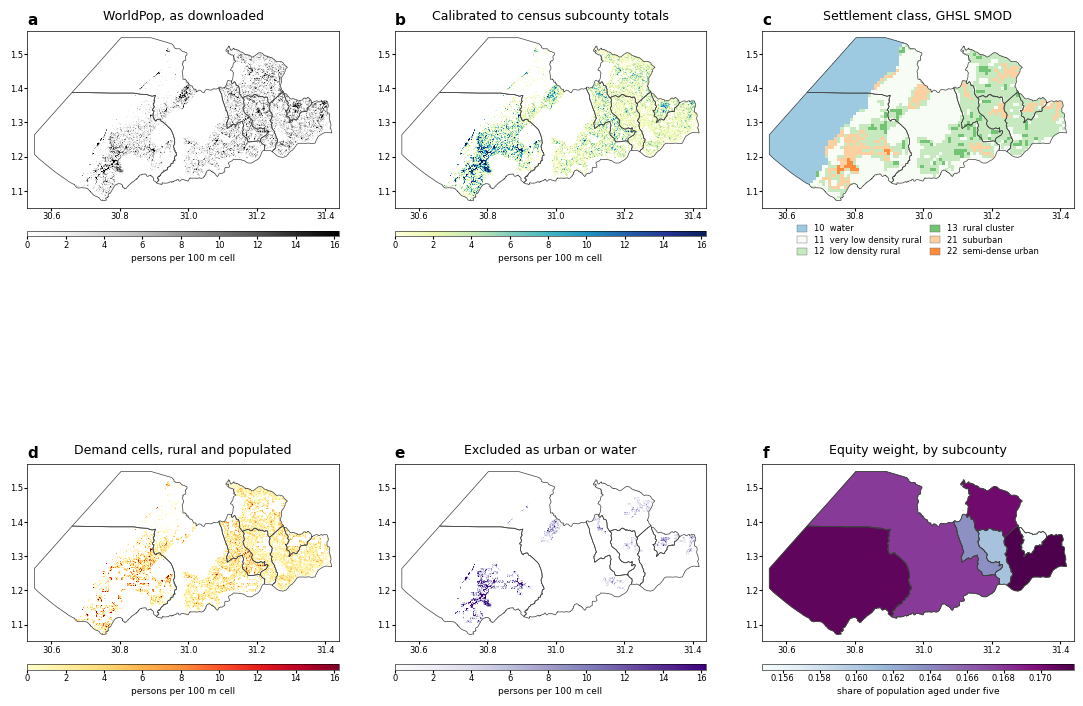

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from matplotlib.patches import Patch
from rasterio.transform import array_bounds

# The raster extent is the clip of cells carrying data, which stops short of the
# administrative boundary wherever WorldPop has no values. EXT positions the
# raster; the axes are framed on the sub-county outline instead, so that no part
# of the district is cut off.
left, bottom, right, top = array_bounds(H, W, transform)
EXT = [left, right, bottom, top]

PAD = 0.02                                   # degrees, roughly 2 km
bx0, by0, bx1, by1 = sub.total_bounds
XLIM = (min(left, bx0) - PAD, max(right, bx1) + PAD)
YLIM = (min(bottom, by0) - PAD, max(top, by1) + PAD)


def frame(ax, title, letter):
    sub.boundary.plot(ax=ax, color="0.25", linewidth=0.5, zorder=5)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9, pad=8)
    ax.text(0.0, 1.02, letter, transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="bottom")
    ax.tick_params(labelsize=6, length=2, pad=1)
    for s in ax.spines.values():
        s.set_linewidth(0.5)


def bar(ax, mappable, label):
    """Colourbar below the axes, outside the plotting area."""
    cax = ax.inset_axes([0.0, -0.16, 1.0, 0.030])
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.ax.tick_params(labelsize=6, length=2, pad=1)
    cb.set_label(label, fontsize=6.5, labelpad=3)
    cb.outline.set_linewidth(0.4)


fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.6))
pos = pop_cal[np.isfinite(pop_cal) & (pop_cal > 0)]
vmax = np.nanpercentile(pos, 99)

# a. WorldPop as downloaded
ax = axes[0, 0]
im = ax.imshow(np.where(pop_raw > 0, pop_raw, np.nan), extent=EXT,
               cmap="Greys", vmin=0, vmax=vmax, interpolation="nearest")
frame(ax, "WorldPop, as downloaded", "a")
bar(ax, im, "persons per 100 m cell")

# b. After calibration to census subcounty totals
ax = axes[0, 1]
im = ax.imshow(np.where(pop_cal > 0, pop_cal, np.nan), extent=EXT,
               cmap="YlGnBu", vmin=0, vmax=vmax, interpolation="nearest")
frame(ax, "Calibrated to census subcounty totals", "b")
bar(ax, im, "persons per 100 m cell")

# c. Settlement class. Drawn over every cell inside a subcounty, not only those
# where WorldPop has data, so that the lake appears rather than reading as blank.
ax = axes[0, 2]
inside = sub_id >= 0
colours = {10: "#9ecae1", 11: "#f7fcf5", 12: "#c7e9c0", 13: "#74c476",
           21: "#fdd0a2", 22: "#fd8d3c", 23: "#e6550d", 30: "#a63603"}
names = {10: "water", 11: "very low density rural", 12: "low density rural",
         13: "rural cluster", 21: "suburban", 22: "semi-dense urban",
         23: "dense urban", 30: "urban centre"}
present = [c for c in sorted(colours) if ((smod == c) & inside).any()]
cmap = ListedColormap([colours[c] for c in present])
coded = np.full(smod.shape, np.nan)
for i, c in enumerate(present):
    coded[(smod == c) & inside] = i
ax.imshow(coded, extent=EXT, cmap=cmap,
          norm=BoundaryNorm(range(len(present) + 1), cmap.N),
          interpolation="nearest")
frame(ax, "Settlement class, GHSL SMOD", "c")
ax.legend(handles=[Patch(facecolor=colours[c], edgecolor="0.4",
                         linewidth=0.3, label=f"{c}  {names[c]}")
                   for c in present],
          loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2,
          fontsize=6, frameon=False, handlelength=1.2,
          handleheight=0.9, labelspacing=0.3, columnspacing=1.0)

# d. Demand cells retained
ax = axes[1, 0]
dem = np.full(pop_cal.shape, np.nan)
dem[keep] = pop_cal[keep]
im = ax.imshow(dem, extent=EXT, cmap="YlOrRd", vmin=0, vmax=vmax,
               interpolation="nearest")
frame(ax, "Demand cells, rural and populated", "d")
bar(ax, im, "persons per 100 m cell")

# e. Population dropped as urban or water
ax = axes[1, 1]
drop = np.full(pop_cal.shape, np.nan)
m = is_urban | is_water
drop[m] = pop_cal[m]
im = ax.imshow(drop, extent=EXT, cmap="Purples", vmin=0, vmax=vmax,
               interpolation="nearest")
frame(ax, "Excluded as urban or water", "e")
bar(ax, im, "persons per 100 m cell")

# f. The equity weight, constant within a subcounty. Drawn by hand rather than
# through geopandas so that the axes keeps the same size as the others.
ax = axes[1, 2]
w = sub.merge(demand.groupby("subcounty").share_under5.first().rename("u5"),
              left_on="subcounty", right_index=True, how="left")
norm = Normalize(vmin=w.u5.min(), vmax=w.u5.max())
w.plot(column="u5", ax=ax, cmap="BuPu", norm=norm,
       edgecolor="0.25", linewidth=0.5, legend=False)
frame(ax, "Equity weight, by subcounty", "f")
bar(ax, ScalarMappable(norm=norm, cmap="BuPu"),
    "share of population aged under five")

plt.subplots_adjust(wspace=0.18, hspace=0.42)
plt.savefig(FIG / "06_demand_surface.png", dpi=300, bbox_inches="tight")
plt.show()

The refugee settlement was merged into Kyangwali in 02, so the sub-county it
belongs to is the one where WorldPop falls furthest below the census. That bears
on the refugee settlement limitation: the merged unit averages a settlement with
about 80 per cent improved-source coverage against a host community at about 49
per cent, and results for Kyangwali should not be read as uniform within it.